In [17]:
import pandas as pd
%pip install pandas


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd
pd.__version__

'2.3.3'

In [19]:
from pathlib import Path
ROOT = Path("/Users/mitchellheaton/stat486/STAT486_FINAL")
df = pd.read_csv(ROOT / "data" / "listings.csv")

In [20]:
df = pd.read_csv("data/listings.csv")

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace(r"[\\$,]", "", regex=True)
    .replace(["", "NA", "N/A"], pd.NA)
    .astype("float64")
)

# Look at the dataset immediately
print(df.head())
print(df.info())
print(df.describe(include='all').T)

# superhost vs not
print(df.groupby("host_is_superhost")["price"].agg(["count","mean","median"]))

# geo + price cleanup
df_geo = df.dropna(subset=["latitude","longitude","price"])
print('geo rows:', len(df_geo))

                    id                                       listing_url  \
0  1274691077561855573  https://www.airbnb.com/rooms/1274691077561855573   
1  1274722590671904755  https://www.airbnb.com/rooms/1274722590671904755   
2  1274773188072371454  https://www.airbnb.com/rooms/1274773188072371454   
3  1274820999428562667  https://www.airbnb.com/rooms/1274820999428562667   
4  1274826163511555978  https://www.airbnb.com/rooms/1274826163511555978   

        scrape_id last_scraped       source  \
0  20251101201932   2025-11-02  city scrape   
1  20251101201932   2025-11-02  city scrape   
2  20251101201932   2025-11-02  city scrape   
3  20251101201932   2025-11-02  city scrape   
4  20251101201932   2025-11-02  city scrape   

                                                name  \
0         Beautiful room for rent hosted by Svitlana   
1     Exquisite & Charming Studio in Prime Locations   
2  Private 2 Bedroom Unit, Full Kitchen, Washer/D...   
3           Beautiful, Serene West V

In [22]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36353 entries, 0 to 36352
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36353 non-null  int64  
 1   listing_url                                   36353 non-null  object 
 2   scrape_id                                     36353 non-null  int64  
 3   last_scraped                                  36353 non-null  object 
 4   source                                        36353 non-null  object 
 5   name                                          36351 non-null  object 
 6   description                                   35178 non-null  object 
 7   neighborhood_overview                         18748 non-null  object 
 8   picture_url                                   36353 non-null  object 
 9   host_id                                       36353 non-null 

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.635300e+04,3.635300e+04,3.635300e+04,34896.000000,34896.000000,36353.000000,36353.000000,36353.000000,21703.000000,30273.000000,...,25006.000000,24993.000000,25001.000000,24991.000000,24991.000000,36353.000000,36353.000000,36353.000000,36353.000000,25007.000000
mean,4.795865e+17,2.025110e+13,1.783743e+08,108.307657,185.066999,40.728456,-73.947526,2.749044,1.186472,1.389291,...,4.655314,4.832473,4.820115,4.743166,4.632069,69.546530,50.675130,18.022282,0.069623,0.828382
std,5.543793e+17,0.000000e+00,1.972890e+08,589.676629,897.368023,0.056191,0.054886,1.881061,0.547165,0.946494,...,0.514724,0.389834,0.428888,0.401999,0.507942,222.326274,211.603781,79.225799,1.027847,1.923861
min,2.539000e+03,2.025110e+13,1.678000e+03,1.000000,1.000000,40.504560,-74.251907,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,2.173739e+07,2.025110e+13,1.830550e+07,1.000000,1.000000,40.688330,-73.983640,2.000000,1.000000,1.000000,...,4.540000,4.820000,4.820000,4.660000,4.520000,1.000000,0.000000,0.000000,0.000000,0.070000
50%,5.151022e+07,2.025110e+13,9.135563e+07,2.000000,3.000000,40.726240,-73.955230,2.000000,1.000000,1.000000,...,4.820000,4.950000,4.960000,4.860000,4.760000,2.000000,1.000000,1.000000,0.000000,0.250000
75%,9.937094e+17,2.025110e+13,3.184403e+08,8.000000,11.000000,40.762173,-73.928230,4.000000,1.000000,2.000000,...,5.000000,5.000000,5.000000,5.000000,4.940000,9.000000,2.000000,2.000000,0.000000,0.900000
max,1.544461e+18,2.025110e+13,7.264789e+08,5477.000000,9966.000000,40.911390,-73.711822,16.000000,15.500000,16.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,1178.000000,1178.000000,568.000000,24.000000,121.170000


In [23]:
# base clean
df = df.copy()
df = df.dropna(subset=["price", "latitude", "longitude"])  # if geography needed
df["accommodates"] = pd.to_numeric(df["accommodates"], errors="coerce")
df["bedrooms"] = pd.to_numeric(df["bedrooms"], errors="coerce")
df["beds"] = pd.to_numeric(df["beds"], errors="coerce")

# optional impute fields:
for c in ["bathrooms", "review_scores_rating", "review_scores_cleanliness"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

In [24]:
df = df.dropna(subset=["price"]).copy()
df["bathrooms"] = pd.to_numeric(df["bathrooms"], errors="coerce")
df["bedrooms"] = pd.to_numeric(df["bedrooms"], errors="coerce")
df["beds"] = pd.to_numeric(df["beds"], errors="coerce")
df["number_of_reviews"] = pd.to_numeric(df["number_of_reviews"], errors="coerce")
for c in ["bathrooms","bedrooms","beds","number_of_reviews","review_scores_rating"]:
    df[c] = df[c].fillna(df[c].median())

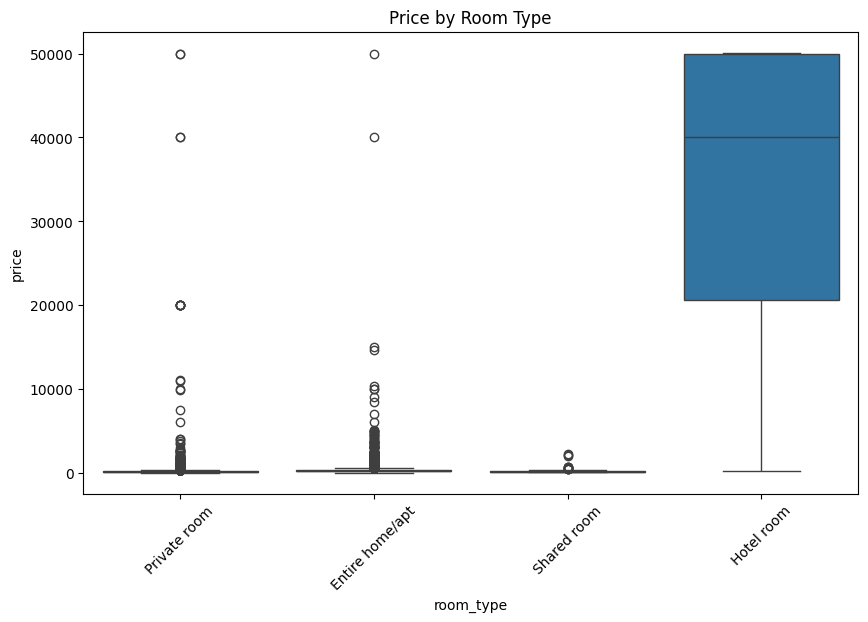

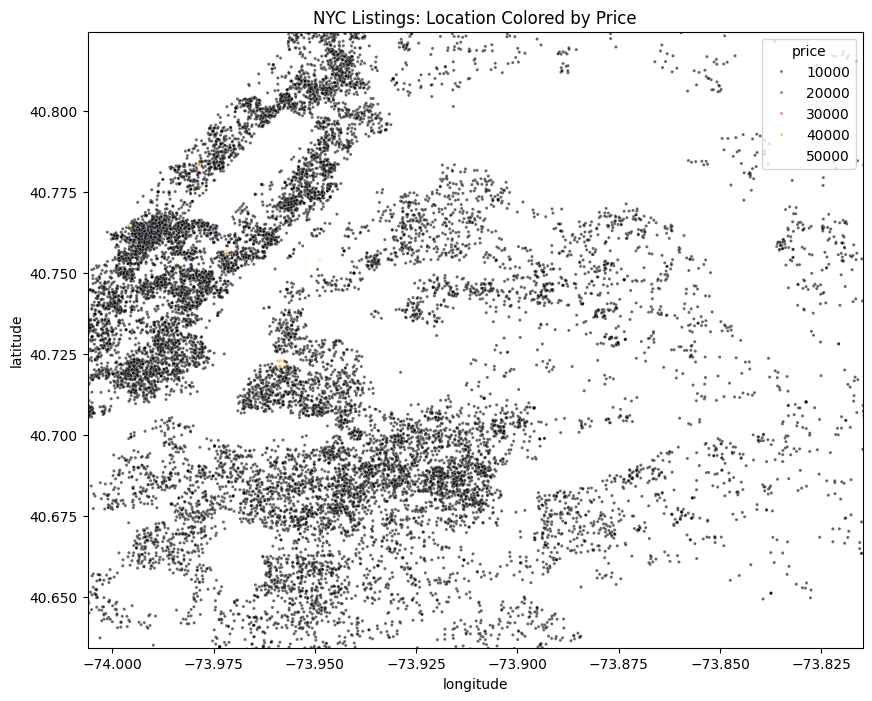

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot (room_type vs price)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="room_type", y="price")
plt.xticks(rotation=45)
plt.title("Price by Room Type")
plt.show()

# Scatterplot (longitude vs latitude, colored by price) - reduced overlap
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_geo, x="longitude", y="latitude", hue="price", palette="inferno", alpha=0.6, s=5)
plt.title("NYC Listings: Location Colored by Price")
plt.xlim(df_geo["longitude"].quantile(0.05), df_geo["longitude"].quantile(0.95))
plt.ylim(df_geo["latitude"].quantile(0.05), df_geo["latitude"].quantile(0.95))
plt.show()